# BikeFlow — Improved Linear Regression Baseline

本 Notebook 研究一个问题：**只改变时间特征的表达方式，同一个 Linear Regression 的预测会怎样变化？**

V0 把 `hour`、`day_of_week`、`month` 当作普通数字；V1 把它们转成 One-Hot 类别列。两个模型使用同一份 `data/processed/bikeflow_2024.csv`、相同天气字段、相同目标和相同的时间顺序 Train/Test 切分。这里不使用历史需求特征。

数据处理依据：`src/data/clean_citibike.py`、`src/data/build_hourly_demand.py`、`src/data/build_model_dataset.py`；建模设置依据：`notebooks/02_baseline_model.ipynb`。本实验直接从已处理的 CSV 开始，不重新生成或修改源数据。

## 1. Experiment Goal

**唯一主要实验变量是时间编码。**预测目标始终是 `ride_count`（每个纽约本地小时开始的骑行次数），算法始终是 `sklearn.linear_model.LinearRegression`。V0 先复现已有 Baseline，再与 V1 比较整体误差、通勤高峰和负预测值。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({"figure.figsize": (12, 4.8), "font.size": 10, "axes.grid": False})

experiment_design = pd.DataFrame({
    "Model": ["V0 Numeric", "V1 One-Hot"],
    "Time representation": ["原始数字", "One-Hot 类别列"],
    "Estimator": ["LinearRegression", "LinearRegression"],
})
display(experiment_design)

,Model,Time representation,Estimator
0,V0 Numeric,原始数字,LinearRegression
1,V1 One-Hot,One-Hot 类别列,LinearRegression


## 2. Load Dataset

读取已有的最终数据集。这里的 `timestamp` 是纽约本地钟表时间。路径同时支持从项目根目录和 `notebooks/` 目录运行。

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("请从 BikeFlow 项目根目录或 notebooks 目录运行")

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"数据文件: {DATA_PATH}")
print(f"原始维度: {data.shape}")
print(f"时间范围: {data['timestamp'].min()} 至 {data['timestamp'].max()}")
print(f"重复 timestamp: {data['timestamp'].duplicated().sum()}")
display(data.head(3))

数据文件: C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始维度: (8784, 10)
时间范围: 2024-01-01 00:00:00 至 2024-12-31 23:00:00
重复 timestamp: 0


,timestamp,ride_count,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2024-01-01 00:00:00,1901,1.8,-2.1,71.0,0.0,0.0,0.0,3.0,9.0
1,2024-01-01 01:00:00,2333,2.4,-1.7,71.0,0.0,0.0,0.0,3.0,10.9
2,2024-01-01 02:00:00,1939,2.4,-1.5,73.0,0.0,0.0,0.0,3.0,10.1


## 3. Prepare Modeling Data

与 02 Baseline 完全一致：春季 `2024-03-10 02:00` 是不存在的小时，需求为 0、天气缺失；秋季 `2024-11-03 01:00` 把两个真实小时合并成一行。两行都从建模数据中排除，使一行代表一个真实小时。其余行不填补、不另行删减。

In [3]:
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
spring_row = data.loc[data["timestamp"].eq(SPRING_GAP)]
fall_row = data.loc[data["timestamp"].eq(FALL_REPEAT)]

assert len(spring_row) == len(fall_row) == 1
assert spring_row["ride_count"].iloc[0] == 0
assert spring_row.drop(columns=["timestamp", "ride_count"]).isna().all(axis=None)

# 与 02 Baseline 一样，排除两个 DST 特殊时间标签。
model_data = data.loc[~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])].copy()
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month
model_data["is_weekend"] = model_data["day_of_week"].ge(5).astype(int)

print(f"排除 DST 特殊行后: {len(model_data):,} 行")
display(model_data[["timestamp", "ride_count", "hour", "day_of_week", "month", "is_weekend"]].head(3))

排除 DST 特殊行后: 8,782 行


,timestamp,ride_count,hour,day_of_week,month,is_weekend
0,2024-01-01 00:00:00,1901,0,0,1,0
1,2024-01-01 01:00:00,2333,1,0,1,0
2,2024-01-01 02:00:00,1939,2,0,1,0


天气字段也与 02 Baseline 一致。真实列名是 `precipitation`，其数值表示时间标签 **t 之前一小时**的累计降水；它不是当前预测小时内的降水。当前气温、湿度、风速来自历史观测，因此这个实验是回顾性比较。若用于提前预测未来小时，这些字段需要相应的天气预报。

最后按时间排序，前 80% 作为 Train，后 20% 作为 Test，不随机切分、不 shuffle。这个切分只做一次，V0 和 V1 共用相同的行与目标。

In [4]:
weather_features = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
]
time_features_v0 = ["hour", "day_of_week", "month", "is_weekend"]

assert set(weather_features).issubset(model_data.columns)
assert all(pd.api.types.is_numeric_dtype(model_data[name]) for name in weather_features)
assert model_data[weather_features].notna().all(axis=None)

# 使用与 Baseline 相同的时间排序和前 80% / 后 20% 划分。
model_data = model_data.sort_values("timestamp").reset_index(drop=True)
split_index = int(len(model_data) * 0.8)
train_time = model_data["timestamp"].iloc[:split_index]
test_time = model_data["timestamp"].iloc[split_index:]
y_train = model_data["ride_count"].iloc[:split_index]
y_test = model_data["ride_count"].iloc[split_index:]

assert train_time.max() < test_time.min()
assert y_train.notna().all() and y_test.notna().all()
print(f"Train start: {train_time.min()}")
print(f"Train end:   {train_time.max()}")
print(f"Test start:  {test_time.min()}")
print(f"Test end:    {test_time.max()}")
print(f"Train/Test rows: {len(y_train):,} / {len(y_test):,}")

Train start: 2024-01-01 00:00:00
Train end:   2024-10-19 17:00:00
Test start:  2024-10-19 18:00:00
Test end:    2024-12-31 23:00:00
Train/Test rows: 7,025 / 1,757


## 4. Model V0 — Numeric Time Features

V0 保留 02 Baseline 的 8 个输入：4 个数字时间字段和 4 个天气字段。`model.fit()` 只看训练期数据；`model.predict()` 只用测试期特征。所有结果保存在带 `_v0` 后缀的变量中。

In [5]:
feature_columns_v0 = time_features_v0 + weather_features
X_train_v0 = model_data[feature_columns_v0].iloc[:split_index]
X_test_v0 = model_data[feature_columns_v0].iloc[split_index:]

assert X_train_v0.notna().all(axis=None) and X_test_v0.notna().all(axis=None)
print(f"V0 features: {feature_columns_v0}")
print(f"X_train_v0 shape: {X_train_v0.shape}")
print(f"X_test_v0 shape:  {X_test_v0.shape}")

V0 features: ['hour', 'day_of_week', 'month', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']
X_train_v0 shape: (7025, 8)
X_test_v0 shape:  (1757, 8)


In [6]:
# V0：拟合原始数字时间特征的 Linear Regression。
model_v0 = LinearRegression()
model_v0.fit(X_train_v0, y_train)
y_pred_v0 = model_v0.predict(X_test_v0)
print(f"V0 已预测 {len(y_pred_v0):,} 个测试小时")

V0 已预测 1,757 个测试小时


## 5. Why One-Hot Encoding?

原来 `hour = 8` 作为一个数字进入 Linear Regression，模型只给 `hour` 学习**一条共同的斜率**。这相当于让 03:00、08:00、17:00、23:00 沿同一条直线变化，很难表示早晚高峰。

One-Hot Encoding 把 `hour` 拆成 `hour_0`、`hour_1`、…、`hour_23` 这样的指示列。08:00 对应 `hour_8 = 1`，其余小时列为 0。模型于是能分别学习凌晨、早高峰、下午与晚间的不同影响。`day_of_week` 也一样：0=周一、…、6=周日是**类别标签**，不能理解成周日是周一的 6 倍。

正式模型采用 `drop_first=True`：省去 `hour_0`、`day_of_week_0`（周一）和 `month_1`（一月）作为基准类别。保留截距时，若每一类的全部 dummy 列都加入，列之间会有完全线性关系；省去一个基准列可以避免这个 dummy variable trap。下方小例子展示 00:00 与 08:00 的编码。

In [7]:
example_hours = pd.DataFrame({"hour": [0, 8]})
example_hours["hour"] = pd.Categorical(example_hours["hour"], categories=range(24))
example_dummies = pd.get_dummies(example_hours, drop_first=True, dtype=int)
example_dummies.insert(0, "original_hour", [0, 8])
display(example_dummies[["original_hour", "hour_3", "hour_8", "hour_17", "hour_23"]])
print("hour_0 是基准类别，所以没有单独的 hour_0 列；其余 hour 列全为 0 时表示 00:00。")

,original_hour,hour_3,hour_8,hour_17,hour_23
0,0,0,0,0,0
1,8,0,1,0,0


hour_0 是基准类别，所以没有单独的 hour_0 列；其余 hour 列全为 0 时表示 00:00。


## 6. Model V1 — One-Hot Time Features

只编码 `hour`、`day_of_week`、`month`。天气列和 V0 完全相同。V1 不再另加 `is_weekend`：周六与周日的 dummy 已完整保留周末信息，若再加 `is_weekend`，它恰好等于 `day_of_week_5 + day_of_week_6`，会产生完全共线。

类别范围（小时 0–23、星期 0–6、月份 1–12）是预先知道的日历知识，不由测试集目标推断。先分别为 Train/Test 建列，再只保留**训练期出现过的列**。因此训练期没有的 11、12 月无法学到月份系数；测试期的这两个月在保留的月份 dummy 上全为 0，相当于落在一月基准类别。这是时间外推限制，结论中会再次说明。

In [8]:
categorical_time_features = ["hour", "day_of_week", "month"]
time_train = model_data[categorical_time_features].iloc[:split_index].copy()
time_test = model_data[categorical_time_features].iloc[split_index:].copy()

# Train/Test 使用相同的日历类别和相同的基准类别。
time_train["hour"] = pd.Categorical(time_train["hour"], categories=range(24))
time_test["hour"] = pd.Categorical(time_test["hour"], categories=range(24))
time_train["day_of_week"] = pd.Categorical(time_train["day_of_week"], categories=range(7))
time_test["day_of_week"] = pd.Categorical(time_test["day_of_week"], categories=range(7))
time_train["month"] = pd.Categorical(time_train["month"], categories=range(1, 13))
time_test["month"] = pd.Categorical(time_test["month"], categories=range(1, 13))

# 对 hour、day_of_week、month 进行 One-Hot Encoding，并省去各自的基准列。
dummy_train = pd.get_dummies(time_train, drop_first=True, dtype=int)
dummy_test = pd.get_dummies(time_test, drop_first=True, dtype=int)

# 训练期全为 0 的列没有可学习的系数；测试列严格对齐训练列。
trained_dummy_columns = dummy_train.columns[dummy_train.any(axis=0)]
dummy_train = dummy_train[trained_dummy_columns]
dummy_test = dummy_test[trained_dummy_columns]
assert dummy_train.columns.equals(dummy_test.columns)

In [9]:
# 保持天气特征与 V0 完全一致，且保留原来的 Train/Test 行索引。
X_train_v1 = pd.concat([
    dummy_train, model_data[weather_features].iloc[:split_index]
], axis=1)
X_test_v1 = pd.concat([
    dummy_test, model_data[weather_features].iloc[split_index:]
], axis=1)

assert X_train_v1.columns.equals(X_test_v1.columns)
assert X_train_v1.index.equals(X_train_v0.index)
assert X_test_v1.index.equals(X_test_v0.index)
assert X_train_v1.notna().all(axis=None) and X_test_v1.notna().all(axis=None)

unseen_test_months = sorted(set(time_test["month"]) - set(time_train["month"]))
print(f"X_train_v0 shape: {X_train_v0.shape} → X_train_v1 shape: {X_train_v1.shape}")
print(f"X_test_v0 shape:  {X_test_v0.shape} → X_test_v1 shape:  {X_test_v1.shape}")
print(f"V1 列数: {len(dummy_train.columns)} 个时间 dummy + {len(weather_features)} 个天气字段")
print(f"hour dummy: {dummy_train.filter(like='hour_').shape[1]} 列")
print(f"day_of_week dummy: {dummy_train.filter(like='day_of_week_').shape[1]} 列")
print(f"month dummy: {dummy_train.filter(like='month_').shape[1]} 列")
print(f"训练集未出现的测试月份: {unseen_test_months}")
print("列数增加是因为每个时间类别有自己的指示列，而不再只占一个数字列。")

X_train_v0 shape: (7025, 8) → X_train_v1 shape: (7025, 42)
X_test_v0 shape:  (1757, 8) → X_test_v1 shape:  (1757, 42)
V1 列数: 38 个时间 dummy + 4 个天气字段
hour dummy: 23 列
day_of_week dummy: 6 列
month dummy: 9 列
训练集未出现的测试月份: [11, 12]
列数增加是因为每个时间类别有自己的指示列，而不再只占一个数字列。


In [10]:
# V1：模型仍然是同一个 LinearRegression 类。
model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train)
y_pred_v1 = model_v1.predict(X_test_v1)
print(f"V1 已预测 {len(y_pred_v1):,} 个测试小时")

V1 已预测 1,757 个测试小时


## 7. Model Comparison

MAE 和 RMSE 的单位都是**次骑行/小时**，越小越好；RMSE 对大误差更敏感。R² 越高越好，也可能为负。改善百分比以 V0 为分母：`(V0 − V1) / V0 × 100%`；若为负，就表示 V1 变差。R² 直接报告两模型之差。

In [11]:
mae_v0 = mean_absolute_error(y_test, y_pred_v0)
rmse_v0 = np.sqrt(mean_squared_error(y_test, y_pred_v0))
r2_v0 = r2_score(y_test, y_pred_v0)

mae_v1 = mean_absolute_error(y_test, y_pred_v1)
rmse_v1 = np.sqrt(mean_squared_error(y_test, y_pred_v1))
r2_v1 = r2_score(y_test, y_pred_v1)

model_results = pd.DataFrame({
    "Model": ["V0 Numeric", "V1 One-Hot"],
    "MAE": [mae_v0, mae_v1],
    "RMSE": [rmse_v0, rmse_v1],
    "R²": [r2_v0, r2_v1],
}).set_index("Model")
display(model_results.round({"MAE": 2, "RMSE": 2, "R²": 3}))

,MAE,RMSE,R²
Model,,,
V0 Numeric,2039.15,2722.81,0.513
V1 One-Hot,1513.90,1956.46,0.748


In [12]:
mae_improvement_pct = (mae_v0 - mae_v1) / mae_v0 * 100
rmse_improvement_pct = (rmse_v0 - rmse_v1) / rmse_v0 * 100
r2_gain = r2_v1 - r2_v0

print(f"V1 MAE 改善: {mae_improvement_pct:+.2f}%")
print(f"V1 RMSE 改善: {rmse_improvement_pct:+.2f}%")
print(f"V1 R² 变化: {r2_gain:+.3f}")

V1 MAE 改善: +25.76%
V1 RMSE 改善: +28.15%
V1 R² 变化: +0.236


## 8. Commute Peak Analysis

沿用 02 Baseline 的高峰定义：**工作日早高峰 07:00–09:00，晚高峰 16:00–19:00**。`mean_error = actual − prediction`，正数表示平均低估；同时看 MAE，避免正负误差互相抵消。V0 与 V1 对比的是完全相同的测试小时。

In [13]:
results = pd.DataFrame({
    "timestamp": test_time.to_numpy(),
    "actual": y_test.to_numpy(),
    "v0_prediction": y_pred_v0,
    "v1_prediction": y_pred_v1,
})
results["hour"] = results["timestamp"].dt.hour
results["day_of_week"] = results["timestamp"].dt.dayofweek
weekday_results = results.loc[results["day_of_week"] < 5]

peak_rows = []
for period, hours in [
    ("Morning 07–09", [7, 8, 9]),
    ("Evening 16–19", [16, 17, 18, 19]),
    ("All commute hours", [7, 8, 9, 16, 17, 18, 19]),
]:
    peak = weekday_results.loc[weekday_results["hour"].isin(hours)]
    peak_rows.append({
        "Period": period,
        "Hours": len(peak),
        "Actual mean": peak["actual"].mean(),
        "V0 predicted mean": peak["v0_prediction"].mean(),
        "V1 predicted mean": peak["v1_prediction"].mean(),
        "V0 mean error": (peak["actual"] - peak["v0_prediction"]).mean(),
        "V1 mean error": (peak["actual"] - peak["v1_prediction"]).mean(),
        "V0 MAE": (peak["actual"] - peak["v0_prediction"]).abs().mean(),
        "V1 MAE": (peak["actual"] - peak["v1_prediction"]).abs().mean(),
    })

peak_comparison = pd.DataFrame(peak_rows).set_index("Period")
display(peak_comparison.round(1))

,Hours,Actual mean,V0 predicted mean,V1 predicted mean,V0 mean error,V1 mean error,V0 MAE,V1 MAE
Period,,,,,,,,
Morning 07–09,156,7278.6,3201.0,5331.9,4077.6,1946.7,4171.4,2696.5
Evening 16–19,208,9081.4,6734.4,8844.4,2347.0,237.0,2939.2,2131.2
All commute hours,364,8308.8,5220.1,7339.0,3088.7,969.8,3467.3,2373.5


## 9. Actual vs Prediction

选择测试集内同一段连续 7 天（2024-10-21 至 2024-10-27），叠加真实需求和两套预测。只展示这一周，方便看清每日形状与工作日早晚高峰。

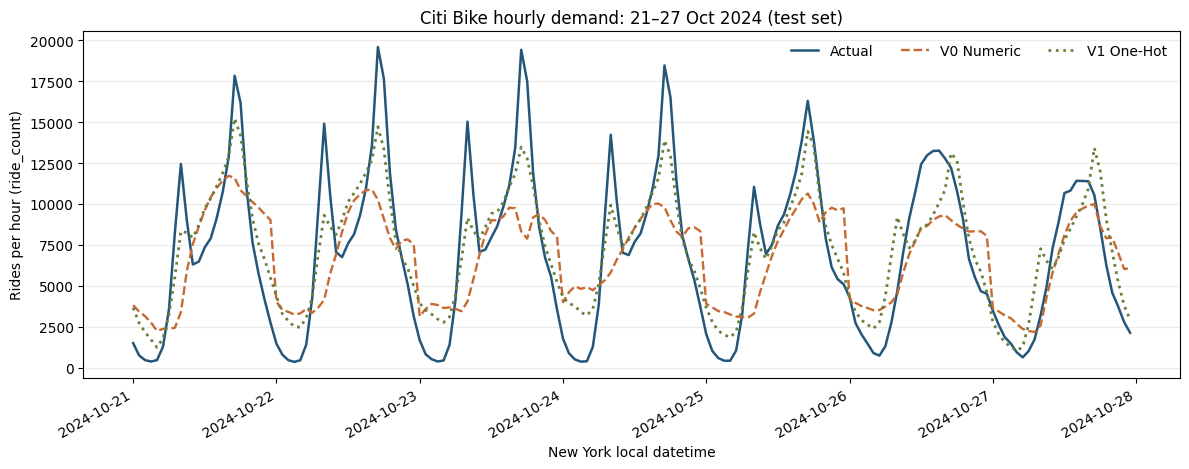

In [14]:
week_start = pd.Timestamp("2024-10-21 00:00")
week_end = week_start + pd.Timedelta(days=7)
one_week = results.loc[
    results["timestamp"].ge(week_start) & results["timestamp"].lt(week_end)
]
assert len(one_week) == 7 * 24
assert one_week["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()

fig, ax = plt.subplots()
ax.plot(one_week["timestamp"], one_week["actual"],
        color="#24567A", linewidth=1.8, label="Actual")
ax.plot(one_week["timestamp"], one_week["v0_prediction"],
        color="#C66A32", linestyle="--", linewidth=1.7, label="V0 Numeric")
ax.plot(one_week["timestamp"], one_week["v1_prediction"],
        color="#69803C", linestyle=":", linewidth=2.0, label="V1 One-Hot")
ax.set(title="Citi Bike hourly demand: 21–27 Oct 2024 (test set)",
       xlabel="New York local datetime", ylabel="Rides per hour (ride_count)")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

这七天里，V1 比 V0 更能跟随多次高峰，但逐小时仍有明显偏差，尤其部分早高峰仍偏低。第 8 节的分组误差表提供了比单周图更稳妥的量化比较。

## 10. Hourly Demand Pattern

只取**测试集的工作日**，按 `hour` 求平均，直接观察 08:00 和 17:00 附近的通勤形状。每条线的 24 个点对应相同的测试行。平均曲线展示系统性模式，但不能代替逐小时的 MAE。

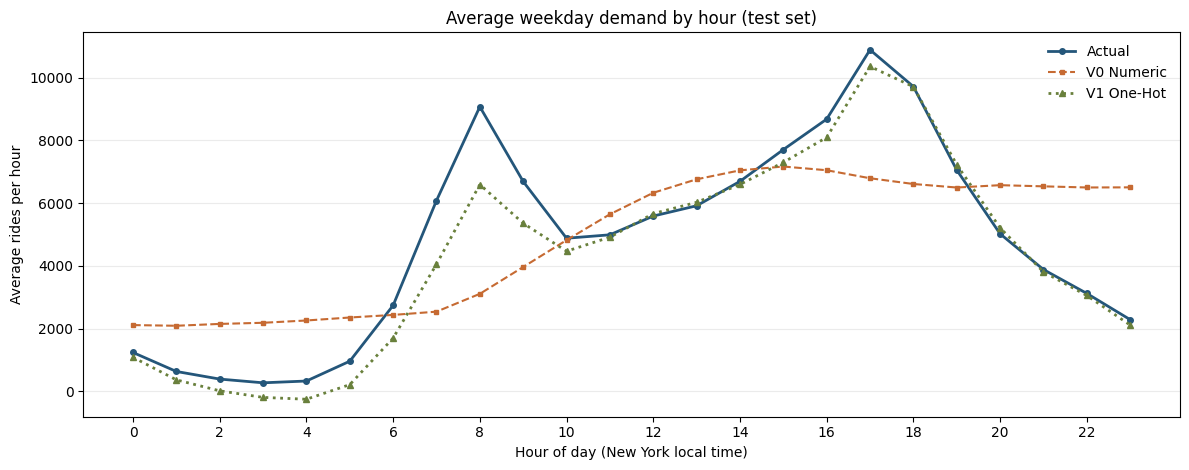

In [15]:
hourly_pattern = weekday_results.groupby("hour")[[
    "actual", "v0_prediction", "v1_prediction"
]].mean()

fig, ax = plt.subplots()
ax.plot(hourly_pattern.index, hourly_pattern["actual"],
        color="#24567A", marker="o", markersize=4, linewidth=2, label="Actual")
ax.plot(hourly_pattern.index, hourly_pattern["v0_prediction"],
        color="#C66A32", linestyle="--", marker="s", markersize=3, label="V0 Numeric")
ax.plot(hourly_pattern.index, hourly_pattern["v1_prediction"],
        color="#69803C", linestyle=":", marker="^", markersize=4, linewidth=2, label="V1 One-Hot")
ax.set(title="Average weekday demand by hour (test set)",
       xlabel="Hour of day (New York local time)", ylabel="Average rides per hour")
ax.set_xticks(range(0, 24, 2))
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

V0 的工作日平均曲线难以形成清晰的早晚双峰；V1 更接近真实的 08:00 和 17:00 形状。V1 在 08:00 仍低估，凌晨部分小时的平均预测还低于零，下一节会统计全部测试小时中的负预测。

## 11. Negative Prediction Analysis

骑行次数不可能小于 0，但普通 Linear Regression 的输出没有非负约束：截距与各特征贡献相加后可能为负。这里保留原始预测，**不使用 `clip(0)`**，以免掩盖模型问题或改变评价结果。

In [16]:
negative_v0 = int((y_pred_v0 < 0).sum())
negative_v1 = int((y_pred_v1 < 0).sum())
negative_results = pd.DataFrame({
    "Model": ["V0 Numeric", "V1 One-Hot"],
    "Negative predictions": [negative_v0, negative_v1],
    "Test hours": [len(y_test), len(y_test)],
})
display(negative_results)

,Model,Negative predictions,Test hours
0,V0 Numeric,51,1757
1,V1 One-Hot,258,1757


## 12. Inspect Time Feature Coefficients

以下只展示几个小时的 V1 coefficient。`hour_0` 是省去的基准小时，没有独立 coefficient。其他 `hour_*` 系数表示：在模型的**加法形式**中，控制其余已加入的特征后，该小时相对 00:00 的预测需求差异。它是模型参数，不应被解释为该小时本身造成的因果效应。

In [17]:
v1_coefficients = pd.Series(model_v1.coef_, index=X_train_v1.columns)
selected_hours = [0, 3, 8, 12, 17, 18, 23]
hour_coefficient_rows = []

for hour in selected_hours:
    if hour == 0:
        hour_coefficient_rows.append({
            "Hour": hour, "Feature": "hour_0 (reference)", "Coefficient vs 00:00": np.nan
        })
    else:
        feature_name = f"hour_{hour}"
        hour_coefficient_rows.append({
            "Hour": hour, "Feature": feature_name,
            "Coefficient vs 00:00": v1_coefficients[feature_name]
        })

hour_coefficients = pd.DataFrame(hour_coefficient_rows).set_index("Hour")
display(hour_coefficients.round(1))

,Feature,Coefficient vs 00:00
Hour,,
0,hour_0 (reference),NaN
3,hour_3,-967.2
8,hour_8,5821.7
12,hour_12,3243.1
17,hour_17,8185.6
18,hour_18,7799.6
23,hour_23,910.2


## 13. What Did We Learn?

下面的结论由本 Notebook 本次运行的指标与高峰表生成，数值不手填。正的平均误差表示低估。

In [18]:
if mae_improvement_pct > 0 and rmse_improvement_pct > 0 and r2_gain > 0:
    overall_message = "V1 在本测试集的三个整体指标上都优于 V0。"
else:
    overall_message = "V1 没有在所有整体指标上同时优于 V0，应分别查看各项结果。"

morning = peak_comparison.loc["Morning 07–09"]
evening = peak_comparison.loc["Evening 16–19"]
all_commute = peak_comparison.loc["All commute hours"]

display(Markdown(f'''
1. **整体性能：**{overall_message}MAE 为 **{mae_v0:,.2f} → {mae_v1:,.2f}** 次/小时（改善 {mae_improvement_pct:.2f}%）；RMSE 为 **{rmse_v0:,.2f} → {rmse_v1:,.2f}** 次/小时（改善 {rmse_improvement_pct:.2f}%）；R² 为 **{r2_v0:.3f} → {r2_v1:.3f}**（变化 {r2_gain:+.3f}）。
2. **通勤高峰：**早高峰平均误差从 **{morning['V0 mean error']:,.1f}** 降到 **{morning['V1 mean error']:,.1f}** 次/小时；晚高峰从 **{evening['V0 mean error']:,.1f}** 降到 **{evening['V1 mean error']:,.1f}**。全部工作日通勤小时从 **{all_commute['V0 mean error']:,.1f}** 降到 **{all_commute['V1 mean error']:,.1f}**。V1 仍低估早高峰。
3. **为什么表达方式重要：**V0 对每个数字时间字段只有一个线性斜率；V1 给不同小时、星期和已见月份各自的偏移，因此同一个 Linear Regression 能学到更接近真实的日内形状。
4. **仍有的限制：**V1 有 **{negative_v1}** 个负预测（V0 为 {negative_v0}）；模型仍是加法形式，没有单独学习“工作日 08:00”与“周末 08:00”的不同组合。训练期没有 11、12 月，因此这两个月的月份效应无法从训练数据估计，测试时落在一月基准。当前天气字段是历史观测；实际提前预测需换成可用的天气预报。
'''))


1. **整体性能：**V1 在本测试集的三个整体指标上都优于 V0。MAE 为 **2,039.15 → 1,513.90** 次/小时（改善 25.76%）；RMSE 为 **2,722.81 → 1,956.46** 次/小时（改善 28.15%）；R² 为 **0.513 → 0.748**（变化 +0.236）。
2. **通勤高峰：**早高峰平均误差从 **4,077.6** 降到 **1,946.7** 次/小时；晚高峰从 **2,347.0** 降到 **237.0**。全部工作日通勤小时从 **3,088.7** 降到 **969.8**。V1 仍低估早高峰。
3. **为什么表达方式重要：**V0 对每个数字时间字段只有一个线性斜率；V1 给不同小时、星期和已见月份各自的偏移，因此同一个 Linear Regression 能学到更接近真实的日内形状。
4. **仍有的限制：**V1 有 **258** 个负预测（V0 为 51）；模型仍是加法形式，没有单独学习“工作日 08:00”与“周末 08:00”的不同组合。训练期没有 11、12 月，因此这两个月的月份效应无法从训练数据估计，测试时落在一月基准。当前天气字段是历史观测；实际提前预测需换成可用的天气预报。


## 14. Next Step

下一阶段单独开展 **Lag Features Experiment**，可能测试：

- `lag_1`：上一小时需求。
- `lag_24`：昨天同一小时需求。
- `lag_168`：上周同一小时需求。

这些历史需求特征**没有在本 Notebook 中构造或用于训练**。下一阶段仍需严格检查时间对齐，尤其是 DST 特殊小时。